<a href="https://colab.research.google.com/github/VENNELA2132/NN-practise/blob/main/Neural_Networks_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [81]:
def f(x):
  return 3*x**2 - 4*x + 5

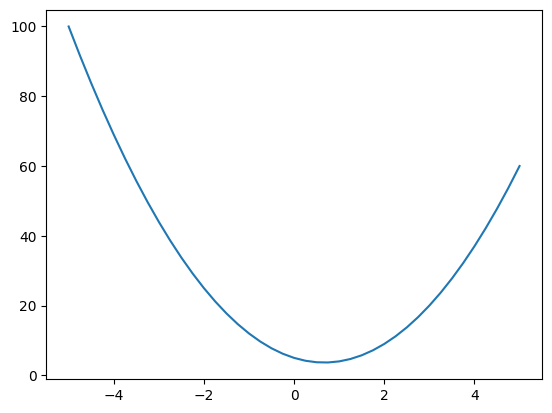

In [82]:
xs = np.arange(-5,5.25,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [117]:
from IPython.utils.openpy import read_py_url
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._prev = set(_children)
    self._backward = lambda: None
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    # print(self.label, self.data, self.grad, ",", other.label, other.data, other.grad, "out",out.data, out.label, out.grad)
    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    n = self.data
    t = (math.exp(2*n)-1) / (math.exp(2*n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    # print("topo\n",topo)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [118]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label='e'
d = e + c; d.label='d'
f = Value(-2, label='f')
L = d * f; L.label='L'
L

Value(data=-8.0)

In [119]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [121]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
L.data

-7.286496

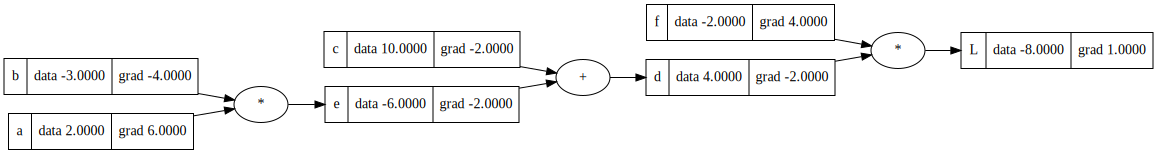

In [120]:
L.grad = 1.0
d.grad = f.data
f.grad = d.data
e.grad = f.data
c.grad = f.data
a.grad = (b * f).data
b.grad = (a * f).data

draw_dot(L)

In [122]:
L

Value(data=-7.286496)

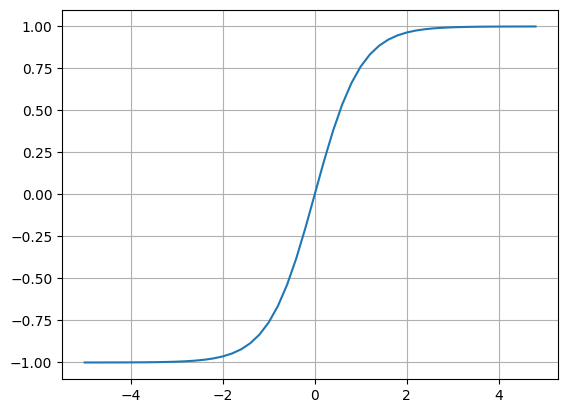

In [123]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [124]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

# #w1.grad = w1x1.grad * x1
# w1.grad = 0.5 * x1.data
# x1.grad = 0.5 * w1.data
# x2.grad = 0.5 * w2.data
# w2.grad = 0.5 * x2.data
# x2w2.grad = 0.5
# x1w1.grad = 0.5
# b.grad = 0.5
# x1w1x2w2.grad = 0.5
# # n.grad = 1 - (o.data * o.data)
# n.grad = 0.5
# o.grad = 1

# o.grad = 1
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x2w2._backward()
# x1w1._backward()



In [125]:
# o.grad = 1.0

# topo = []
# visited = set()
# def build_topo(v):
#   if v not in visited:
#     visited.add(v)
#     for child in v._prev:
#       build_topo(child)
#     topo.append(v)
# build_topo(o)

# for node in reversed(topo):
#   node._backward()

# topo

o.backward()

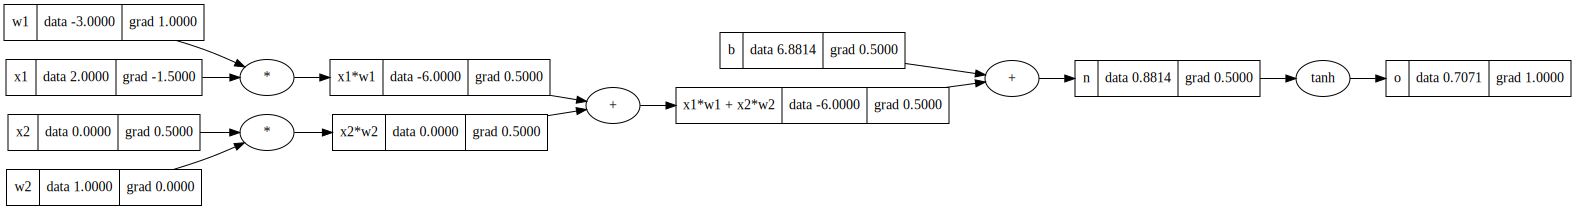

In [126]:
draw_dot(o)

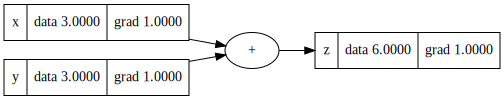

In [127]:
x = Value(data=3.0, label='x')
y = Value(data=3.0, label = 'y')
z = x + y   ; z.label = 'z'
z.backward()
# print(a.grad,b.grad,c.grad)
draw_dot(z)

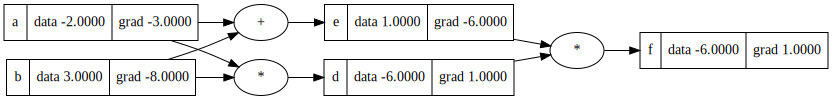

In [128]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)